In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import sqlite3
from rubin_sim.data import get_baseline
import matplotlib.pyplot as plt
%matplotlib inline
import healpy as hp

In [3]:
# or replace with any local file you want to use
baseline_db = get_baseline()
print(baseline_db)

/home/bregeon/Rubin/FINK/rubin_sim/rubin_sim_data/sim_baseline/baseline_v2.0_10yrs.db


In [4]:
conn = sqlite3.connect(baseline_db)

In [5]:
# In the near future, 'summaryallprops' will be replaced with 'observations'
df = pd.read_sql('select * from observations;', conn)

In [6]:
# Make any changes you want to the dataframe
df

,observationId,fieldRA,fieldDec,observationStartMJD,flush_by_mjd,visitExposureTime,filter,rotSkyPos,numExposures,airmass,...,moonAz,sunAz,sunRA,sunDec,moonRA,moonDec,moonDistance,solarElong,moonPhase,cummTelAz
0,0,310.024480,-60.812928,60218.001806,60218.023576,30.0,y,62.750775,2,1.172534,...,78.824163,255.593220,3.257553,-0.050105,27.609463,11.956111,94.490314,102.958651,87.407902,169.454444
1,1,310.601871,-63.561425,60218.002254,60218.023576,30.0,y,61.084250,2,1.207046,...,78.744948,255.500445,3.257560,-0.050108,27.615338,11.959438,95.029204,101.743959,87.404494,170.502875
2,2,311.292611,-66.317774,60218.002703,60218.023576,30.0,y,60.726189,2,1.248190,...,78.665665,255.407493,3.257567,-0.050111,27.621208,11.962765,95.563446,100.497860,87.401088,171.406738
3,3,312.140731,-69.082666,60218.003152,60218.023576,30.0,y,60.656781,2,1.295605,...,78.586315,255.314364,3.257574,-0.050115,27.627073,11.966093,96.092842,99.221261,87.397685,172.197791
4,4,304.170163,-73.375442,60218.003624,60218.023576,30.0,y,49.095537,2,1.371481,...,78.502749,255.216183,3.257582,-0.050118,27.633237,11.969596,99.605374,94.821142,87.394108,177.239803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2086975,2086975,338.528926,-55.399555,63870.104267,63870.135780,30.0,y,334.771589,2,1.105397,...,259.819978,226.970400,3.250349,-0.047002,256.910244,-17.679842,70.801365,117.615117,39.323617,-120.359102
2086976,2086976,347.380828,-54.922128,63870.104758,63870.135780,30.0,y,352.208194,2,1.112273,...,259.743158,226.774631,3.250357,-0.047006,256.916126,-17.679412,75.871877,120.318717,39.326444,-131.999093
2086977,2086977,350.974688,-52.986827,63870.105219,63870.135780,30.0,y,0.553699,2,1.104716,...,259.671193,226.590591,3.250364,-0.047009,256.921640,-17.679010,78.348928,122.861886,39.329094,-138.401088
2086978,2086978,356.062503,-53.778759,63870.105677,63870.135780,30.0,y,8.448490,2,1.127202,...,259.599480,226.406575,3.250371,-0.047012,256.927139,-17.678608,81.048225,122.892555,39.331738,-143.001407


In [7]:
conn.close()

In [8]:
import numpy as np
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
from astropy import units as u

In [9]:
# Take the time and ra/dec of GW170817 in the future as GRB270817
print('One GRB')
grb_datetime = '2027-08-17T12:41:04.4'
grb_time = Time(grb_datetime, format='isot', scale='utc')
print(f'mjd = {grb_time.mjd} for date_time = {grb_time.fits}')
#grb_ra = "19h09m48.08s"   # ra= 13h 09m 48.08s   J2000
#grb_dec = "-23d22m53.3s"  # dec= −23° 22′ 53.3″  J2000
grb_ra = "0h0m0.0s"   # ra= 13h 09m 48.08s   J2000
grb_dec = "+0d00m00.0s"  # dec= −23° 22′ 53.3″  J2000
grb_coord = SkyCoord(grb_ra, grb_dec, frame='icrs')
print(f'GRB coordinates {grb_coord}')

One GRB
mjd = 61634.52852314815 for date_time = 2027-08-17T12:41:04.400
GRB coordinates <SkyCoord (ICRS): (ra, dec) in deg
    (0., 0.)>


/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


In [10]:
# Observe one week before and one month after, need 4 weeks
one_week = TimeDelta(7, format='jd')
four_weeks = TimeDelta(28, format='jd')
obs_start = grb_time - one_week
obs_end = grb_time + four_weeks
print(f'Observations Start {obs_start} / End {obs_end}')
print(f'Observations Start {obs_start.mjd} / End {obs_end.mjd}')

Observations Start 2027-08-10T12:41:04.400 / End 2027-09-14T12:41:04.400
Observations Start 61627.52852314815 / End 61662.52852314815


/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/home/bregeon/data/Soft/miniconda3/envs/orphans/lib/python3.9/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


In [11]:
# get time span
df_time = df[df['observationStartMJD']>obs_start.mjd][df['observationStartMJD']<obs_end.mjd]
df_time

/tmp/ipykernel_172793/3278020211.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_time = df[df['observationStartMJD']>obs_start.mjd][df['observationStartMJD']<obs_end.mjd]


,observationId,fieldRA,fieldDec,observationStartMJD,flush_by_mjd,visitExposureTime,filter,rotSkyPos,numExposures,airmass,...,moonAz,sunAz,sunRA,sunDec,moonRA,moonDec,moonDistance,solarElong,moonPhase,cummTelAz
816510,816510,323.101152,-14.565786,61628.201035,61628.244224,30.0,z,225.730536,2,1.039326,...,253.725118,177.415586,2.450110,0.269688,247.956779,-26.337429,70.490587,177.227231,62.374714,7.928940
816511,816511,319.931489,-14.066910,61628.201515,61628.244224,30.0,z,236.727156,2,1.041452,...,253.661582,176.851841,2.450118,0.269685,247.962549,-26.337024,67.857230,178.548356,62.377285,-3.262896
816512,816512,316.781141,-13.534704,61628.201988,61628.244224,30.0,z,246.297521,2,1.047034,...,253.598996,176.300155,2.450126,0.269683,247.968235,-26.336624,65.245346,176.021764,62.379819,-13.481475
816513,816513,313.642158,-12.987290,61628.202450,61628.244224,30.0,z,254.496745,2,1.055975,...,253.537742,175.763622,2.450133,0.269680,247.973804,-26.336232,62.644624,173.017866,62.382301,-22.354858
816514,816514,310.507659,-12.443028,61628.202903,61628.244224,30.0,z,261.290501,2,1.068319,...,253.477526,175.239379,2.450141,0.269678,247.979281,-26.335846,60.045827,169.956895,62.384742,-29.870363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833487,833487,11.108146,-33.607001,61662.407050,0.000000,30.0,z,208.519164,2,1.510368,...,261.121485,93.708913,2.996950,0.062407,334.042505,-7.814217,42.806362,144.942712,89.954531,2.865221
833488,833488,5.346449,-32.213450,61662.407506,0.000000,30.0,z,205.205071,2,1.689279,...,261.042701,93.623689,2.996957,0.062404,334.047682,-7.811529,37.937292,148.635440,89.957393,3.053264
833489,833489,1.952197,-33.447294,61662.407953,0.000000,30.0,z,204.692909,2,1.798955,...,260.965374,93.540178,2.996964,0.062401,334.052762,-7.808894,36.345223,148.636118,89.960202,0.631903
833490,833490,54.046367,-35.636339,61662.409044,0.000000,30.0,z,239.591087,2,1.030399,...,260.776410,93.336667,2.996981,0.062394,334.065173,-7.802471,77.339065,114.392496,89.967062,-3.902986


In [12]:
# Angular separation with SkyCoord.separation
# Rubin FOV is 47 square degree for a 3.5-degree diameter, hence 1.7 deg separation radius.
df_time['Separation'] = SkyCoord(df_time['fieldRA'], df_time['fieldDec'], unit="deg").separation(grb_coord).degree
df_time.head()

,observationId,fieldRA,fieldDec,observationStartMJD,flush_by_mjd,visitExposureTime,filter,rotSkyPos,numExposures,airmass,...,sunAz,sunRA,sunDec,moonRA,moonDec,moonDistance,solarElong,moonPhase,cummTelAz,Separation
816510,816510,323.101152,-14.565786,61628.201035,61628.244224,30.0,z,225.730536,2,1.039326,...,177.415586,2.450110,0.269688,247.956779,-26.337429,70.490587,177.227231,62.374714,7.928940,39.286078
816511,816511,319.931489,-14.066910,61628.201515,61628.244224,30.0,z,236.727156,2,1.041452,...,176.851841,2.450118,0.269685,247.962549,-26.337024,67.857230,178.548356,62.377285,-3.262896,42.070013
816512,816512,316.781141,-13.534704,61628.201988,61628.244224,30.0,z,246.297521,2,1.047034,...,176.300155,2.450126,0.269683,247.968235,-26.336624,65.245346,176.021764,62.379819,-13.481475,44.886603
816513,816513,313.642158,-12.987290,61628.202450,61628.244224,30.0,z,254.496745,2,1.055975,...,175.763622,2.450133,0.269680,247.973804,-26.336232,62.644624,173.017866,62.382301,-22.354858,47.739839
816514,816514,310.507659,-12.443028,61628.202903,61628.244224,30.0,z,261.290501,2,1.068319,...,175.239379,2.450141,0.269678,247.979281,-26.335846,60.045827,169.956895,62.384742,-29.870363,50.632488


Text(0.5, 1.0, 'One Month Map Ra/Dec')

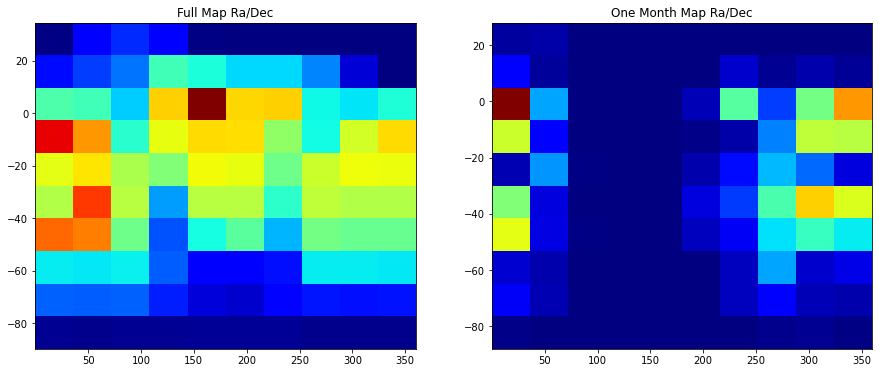

In [13]:
plt.rcParams["figure.figsize"] = [15, 6]
m_fig, m_ax = plt.subplots(1, 2)
m_ax.flatten()
_fm = m_ax[0].hist2d(df['fieldRA'], df['fieldDec'], cmap=plt.cm.jet)
m_ax[0].set_title('Full Map Ra/Dec')
_om = m_ax[1].hist2d(df_time['fieldRA'], df_time['fieldDec'], cmap=plt.cm.jet)
m_ax[1].set_title('One Month Map Ra/Dec')


In [14]:
df_sky = df_time[df_time['Separation']<1.7]
df_sky

,observationId,fieldRA,fieldDec,observationStartMJD,flush_by_mjd,visitExposureTime,filter,rotSkyPos,numExposures,airmass,...,sunAz,sunRA,sunDec,moonRA,moonDec,moonDistance,solarElong,moonPhase,cummTelAz,Separation
816723,816723,358.972375,-0.627173,61628.300934,61628.332300,30.0,z,229.534554,2,1.150900,...,105.988016,2.451761,0.269175,249.318518,-26.241100,107.266505,139.229044,62.989384,84.635982,1.203876
816773,816773,358.972375,-0.627173,61628.325076,61628.332300,30.0,y,244.565343,2,1.158488,...,99.668746,2.452160,0.269051,249.695138,-26.218999,106.936894,139.252199,63.161799,84.411000,1.203876
817518,817518,0.332428,1.198958,61630.211850,61630.249094,30.0,z,192.212265,2,1.407769,...,165.529669,2.483268,0.259234,275.273995,-26.235906,86.100942,139.078986,74.884871,117.560110,1.244183
817568,817568,0.332428,1.198958,61630.235838,61630.249094,30.0,y,199.913148,2,1.292411,...,140.992512,2.483662,0.259108,275.518736,-26.159983,85.877316,139.101998,74.997320,119.981790,1.244183
819302,819302,359.662007,0.954395,61632.260418,61632.295818,30.0,y,99.382906,2,1.201351,...,123.591316,2.516877,0.248299,301.392031,-21.053943,61.003471,141.755929,87.355800,45.252378,1.012471
819352,819352,359.662007,0.954395,61632.284361,61632.295818,30.0,z,112.687036,2,1.172897,...,113.192258,2.517268,0.248170,301.601698,-20.937192,60.785834,141.778910,87.464022,46.024539,1.012471
822910,822910,0.735275,-0.416192,61640.328023,61640.364484,30.0,i,201.195074,2,1.211570,...,103.193000,2.647704,0.202679,33.898947,19.793118,38.263088,149.079685,61.781535,67.980338,0.844887
822960,822960,0.735275,-0.416192,61640.352039,61640.364484,30.0,z,210.897782,2,1.288976,...,97.709956,2.648090,0.202537,34.082865,19.906469,38.469023,149.102816,61.681756,70.832989,0.844887
823888,823888,0.603687,0.645267,61641.349272,61641.383919,30.0,i,199.019031,2,1.306081,...,98.620121,2.664109,0.196637,47.632332,23.803273,51.085769,149.767155,54.906629,-2.587172,0.883624
823936,823936,0.603687,0.645267,61641.372193,61641.383919,30.0,z,205.921514,2,1.425220,...,93.982482,2.664476,0.196501,47.829941,23.894403,51.286717,149.789247,54.808186,-3.122736,0.883624


In [15]:
df_sky.columns

Index(['observationId', 'fieldRA', 'fieldDec', 'observationStartMJD',
       'flush_by_mjd', 'visitExposureTime', 'filter', 'rotSkyPos',
       'numExposures', 'airmass', 'seeingFwhm500', 'seeingFwhmEff',
       'seeingFwhmGeom', 'skyBrightness', 'night', 'slewTime', 'visitTime',
       'slewDistance', 'fiveSigmaDepth', 'altitude', 'azimuth', 'paraAngle',
       'cloud', 'moonAlt', 'sunAlt', 'note', 'fieldId', 'proposalId',
       'block_id', 'observationStartLST', 'rotTelPos', 'moonAz', 'sunAz',
       'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDistance', 'solarElong',
       'moonPhase', 'cummTelAz', 'Separation'],
      dtype='object')

Text(0.5, 1.0, '5 Sigma Depth')

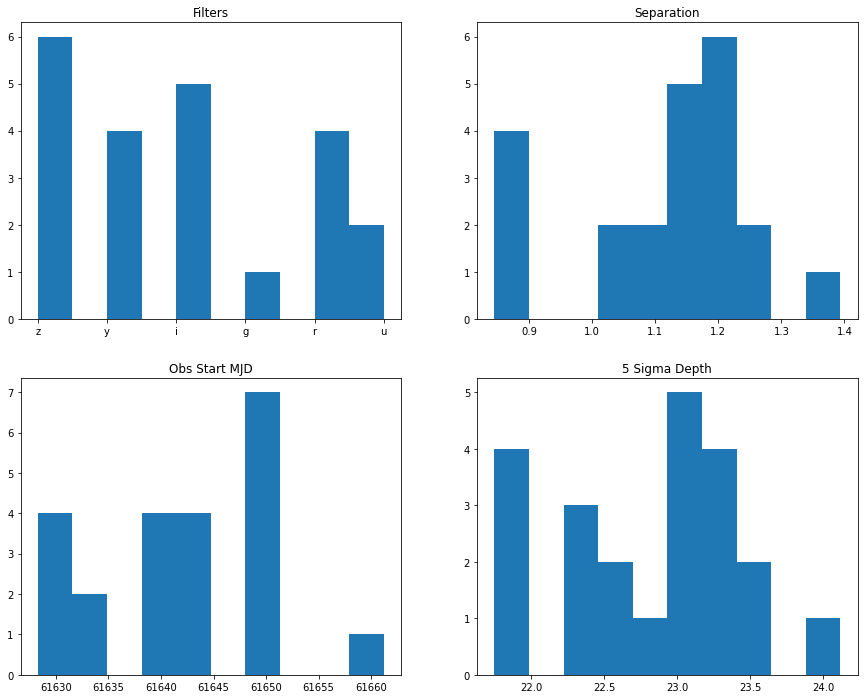

In [16]:
plt.rcParams["figure.figsize"] = [15, 12]
fig, ax = plt.subplots(2, 2)
_filter = ax[0][0].hist(df_sky['filter'])
ax[0][0].set_title('Filters')
_sep = ax[0][1].hist(df_sky['Separation'])
ax[0][1].set_title('Separation')
_mjd = ax[1][0].hist(df_sky['observationStartMJD'])
ax[1][0].set_title('Obs Start MJD')
_depth = ax[1][1].hist(df_sky['fiveSigmaDepth'])
ax[1][1].set_title('5 Sigma Depth')


Text(0.5, 1.0, '5 Sigma depth')

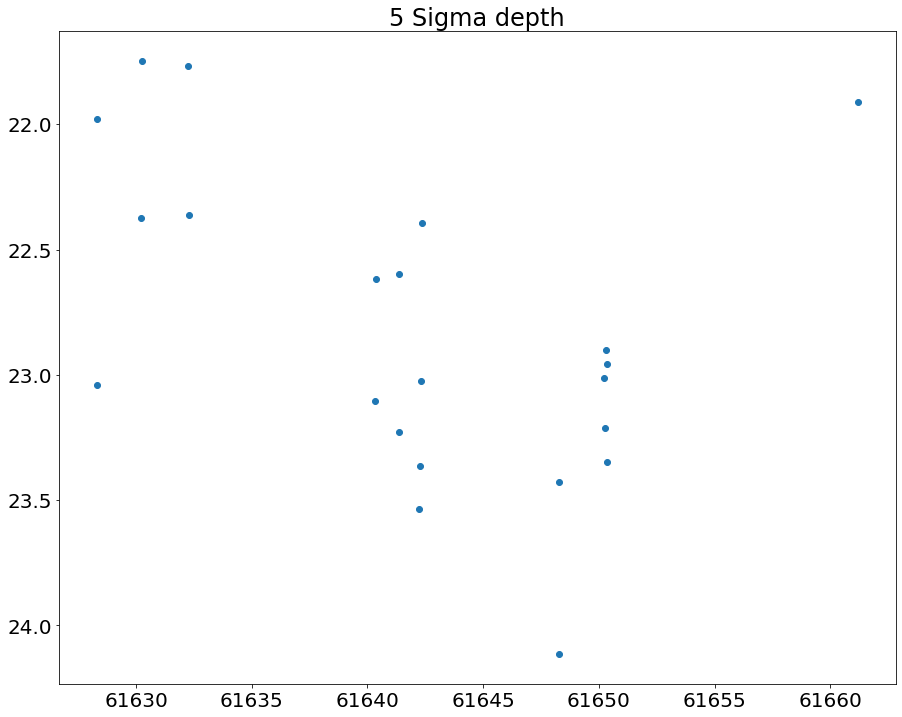

In [17]:
# change axis numbers font size
plt.rcParams["font.size"] = 20
plt.scatter(df_sky['observationStartMJD'], df_sky['fiveSigmaDepth'])
plt.gca().invert_yaxis()
plt.title('5 Sigma depth')

In [18]:
# Import the primary photometry classes from rubin_sim.photUtils
import os
import rubin_sim.photUtils.Bandpass as Bandpass
import rubin_sim.photUtils.Sed as Sed

In [19]:
fdir = '/home/bregeon/Rubin/FINK/rubin_sim/rubin_sim_data'
fdir = os.path.join(fdir, 'throughputs', 'baseline')

# Read the throughput curves
filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'y':'m'}

lsst = {}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].readThroughput(os.path.join(fdir, f'total_{f}.dat'))

In [20]:
# compute observation time in the GRB time frame, i.e. from GRB T_0
obs_times_grb_frame = df_sky['observationStartMJD'] - grb_time.mjd
time_bins = obs_times_grb_frame[obs_times_grb_frame>0]
time_bins.to_dict()

{822910: 5.7994997740970575,
 822960: 5.8235154833237175,
 823888: 6.82074839402776,
 823936: 6.84366983462678,
 824579: 7.6999619410999,
 824629: 7.724042940826621,
 824756: 7.78352065924264,
 824806: 7.808180043612083,
 828384: 13.727887541419477,
 828434: 13.751870276937552,
 830191: 15.698281863660668,
 830241: 15.721857185155386,
 830399: 15.794477471477876,
 830447: 15.81756675725046,
 830488: 15.837480196008983,
 832571: 26.656332808612206}

In [21]:
# compute spectra at observation time bins
import afterglowpy as grb
from orphans.grb_interface import make_grb_spectrum, dump_wl_Fnu_spectrum

Fnu_Jy = dict()
for obs_id, obs_t in time_bins.to_dict().items():
    wl_full_band, freq_full_band, t, Fnu_Jy[obs_id] = make_grb_spectrum(E0=1.0e54, thetaObs=0.1, thetaCore=0.05, t=obs_t * grb.day2sec)


In [22]:
Fnu_Jy

{822910: array([9.33222271e-06, 9.38356275e-06, 9.43492834e-06, ...,
        7.29602096e-05, 7.30220904e-05, 7.30839759e-05]),
 822960: array([9.24260792e-06, 9.29345495e-06, 9.34432729e-06, ...,
        7.22595926e-05, 7.23208791e-05, 7.23821703e-05]),
 823888: array([6.40086474e-06, 6.43607829e-06, 6.47130936e-06, ...,
        5.00425727e-05, 5.00850160e-05, 5.01274626e-05]),
 823936: array([6.36397590e-06, 6.39898651e-06, 6.43401453e-06, ...,
        4.97541722e-05, 4.97963709e-05, 4.98385728e-05]),
 824579: array([4.66012760e-06, 4.68576470e-06, 4.71141455e-06, ...,
        3.64333232e-05, 3.64642239e-05, 3.64951270e-05]),
 824629: array([4.61904049e-06, 4.64445156e-06, 4.66987527e-06, ...,
        3.61121003e-05, 3.61427286e-05, 3.61733592e-05]),
 824756: array([4.52323101e-06, 4.54811499e-06, 4.57301136e-06, ...,
        3.53630526e-05, 3.53930456e-05, 3.54230408e-05]),
 824806: array([4.48512423e-06, 4.50979857e-06, 4.53448519e-06, ...,
        3.50651302e-05, 3.50948704e-05, 3.

In [23]:
def compute_mags(i, wls, fnus, obs_t):
    new_grb_sed = Sed()
    new_grb_sed.wavelen = np.array(wls)
    new_grb_sed.fnu = np.array(fnus)
    # convert fnu to flambda
    new_grb_sed.fnuToflambda()
    # Calculate expected AB magnitudes. 
    new_grb_mags = {}
    for f in filterlist:
        new_grb_mags[f] = new_grb_sed.calcMag(lsst[f])
    # time is one column
    new_grb_mags['obs_time'] = obs_t
    # Make a dataframe just to get a nice output cell.
    return pd.DataFrame(new_grb_mags, index=[i])

In [24]:
# compute magnitudes
obs_list = list()
for obs_id, fnu_val in Fnu_Jy.items():
    obs_t = time_bins[obs_id]
    df = compute_mags(obs_id, wl_full_band, fnu_val, obs_t)
    obs_list.append(df)
obs_df = pd.concat(obs_list)
obs_df

,u,g,r,i,z,y,obs_time
822910,20.753284,20.438896,20.122711,19.892650,19.721897,19.586071,5.799500
822960,20.763760,20.449372,20.133188,19.903126,19.732374,19.596548,5.823515
823888,21.162650,20.848262,20.532077,20.302016,20.131263,19.995437,6.820748
823936,21.168925,20.854537,20.538353,20.308291,20.137539,20.001713,6.843670
824579,21.507252,21.192864,20.876679,20.646618,20.475865,20.340039,7.699962
824629,21.516867,21.202479,20.886295,20.656233,20.485481,20.349655,7.724043
824756,21.539625,21.225237,20.909052,20.678991,20.508238,20.372412,7.783521
824806,21.548810,21.234422,20.918238,20.688177,20.517424,20.381598,7.808180
828384,23.394184,23.079795,22.763611,22.533550,22.362797,22.226971,13.727888
828434,23.401036,23.086647,22.770463,22.540402,22.369649,22.233823,13.751870


In [25]:
# keep only "real" observation for the right filter
x_times = list()
y_mags = list()
z_colors = list()
mags_lim = list()
for obs_id, obs in obs_df.iterrows():
    # obs_id = one[0]
    #obs_time = one[1]['obs_time']
    #print(obs_id, obs_time)
    filt = df_sky[df_sky['observationId']==obs_id]['filter']
    lim = df_sky[df_sky['observationId']==obs_id]['fiveSigmaDepth']
    print(obs_id, obs['obs_time'], filt.values[0], obs[filt].values[0], lim.values[0])
    x_times.append(obs['obs_time'] + grb_time.mjd)
    y_mags.append(obs[filt].values[0])
    z_colors.append(filtercolors[filt.values[0]])
    mags_lim.append(lim.values[0])

822910 5.7994997740970575 i 19.8926499589423 23.10460705445834
822960 5.8235154833237175 z 19.732373636080247 22.61705191351976
823888 6.82074839402776 i 20.30201606994721 23.22710882996377
823936 6.84366983462678 z 20.137538645336637 22.597194237923365
824579 7.6999619410999 g 21.19286395080624 23.533743063822698
824629 7.724042940826621 r 20.88629454500962 23.365543050647
824756 7.78352065924264 i 20.67899077403122 23.023987376772283
824806 7.808180043612083 z 20.51742376892341 22.392731336592945
828384 13.727887541419477 r 22.763610973491375 24.114942751459413
828434 13.751870276937552 i 22.540401686673153 23.429062595686165
830191 15.698281863660668 u 23.840182240736837 23.014582548366377
830241 15.721857185155386 r 23.211415029800023 23.212504744195993
830399 15.794477471477876 u 23.86127530078084 22.901133657826836
830447 15.81756675725046 r 23.23499678751607 23.349251313867924
830488 15.837480196008983 i 23.006656314349975 22.957513921344873
832571 26.656332808612206 y 24.345090

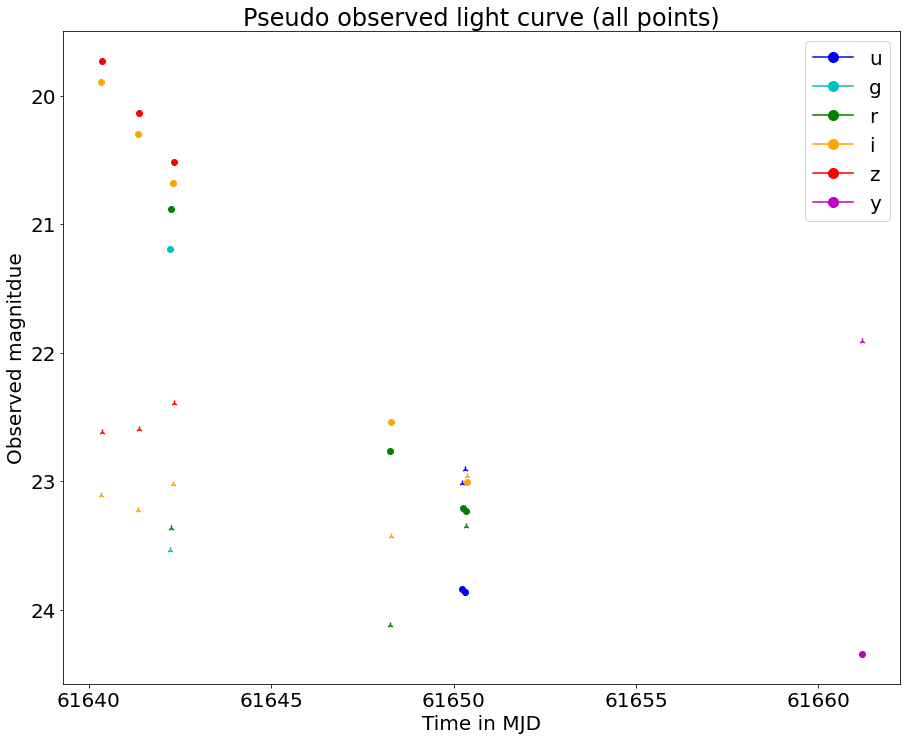

61634.52852314815


In [26]:
from matplotlib.lines import Line2D
# plot pseudo observed light curve
for x, y, z, m in zip(x_times, y_mags, z_colors, mags_lim):
    plt.scatter(x, y, c=z)
    plt.scatter(x, m, c=z, marker='2')
plt.gca().invert_yaxis()
plt.title('Pseudo observed light curve (all points)')
plt.xlabel('Time in MJD')
plt.ylabel('Observed magnitdue')
legend_elements = list()
for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                  markerfacecolor=fcolor, markersize=10))
plt.legend(handles=legend_elements)
plt.show()
print(grb_time.mjd)

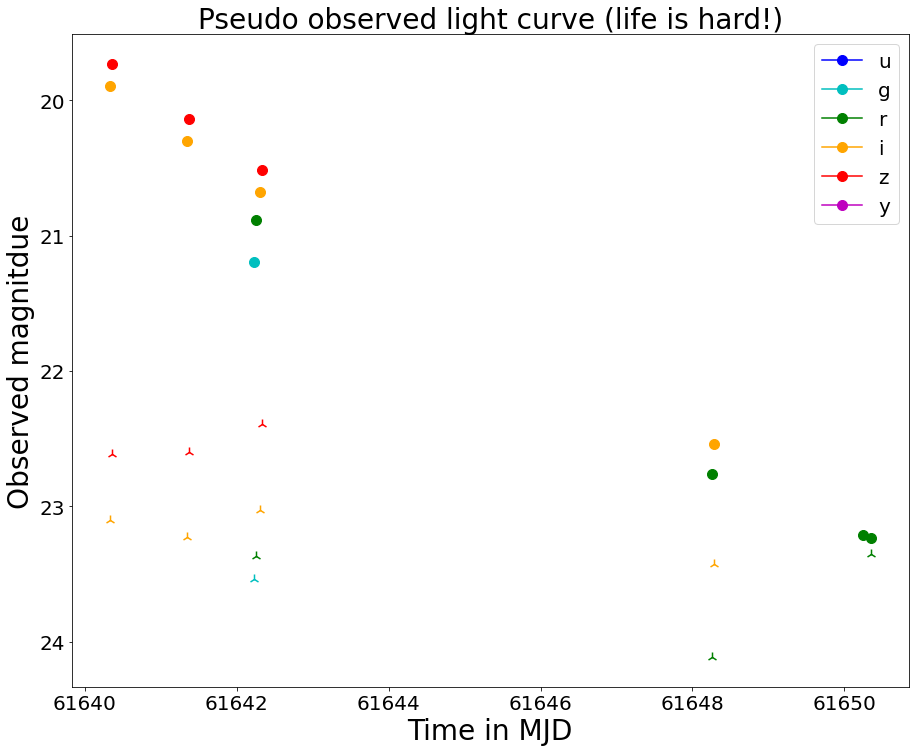

In [27]:
# plot pseudo observed light curve
for x, y, z, m in zip(x_times, y_mags, z_colors, mags_lim):
    if y<m:
        plt.scatter(x, y, c=z, s=100)
        plt.scatter(x, m, c=z, marker='2', s=100)
plt.gca().invert_yaxis()
plt.title('Pseudo observed light curve (life is hard!)', fontsize=28)
plt.xlabel('Time in MJD', fontsize=28)
plt.ylabel('Observed magnitdue', fontsize=28)
legend_elements_2 = list()
for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                  markerfacecolor=fcolor, markersize=10))
plt.legend(handles=legend_elements_2)
plt.show()

In [28]:
from orphans.grb_interface import make_grb_spectrum, make_grb_light_curve, dump_wl_Fnu_spectrum
from orphans.tools import flux_to_mag
full_nu, full_t, full_Fnu_Jy = make_grb_light_curve(E0=1.0e54, thetaObs=0.1, thetaCore=0.05)

In [29]:
def ObsTime(t, mag):
    index = []
    for i in range(len(mag)-1):
        if mag[i] < 24.5:
            index.append(i)
    if not index:
        return 0
    else:
        dt = (t[max(index)] - t[min(index)])*grb.sec2day
        return dt

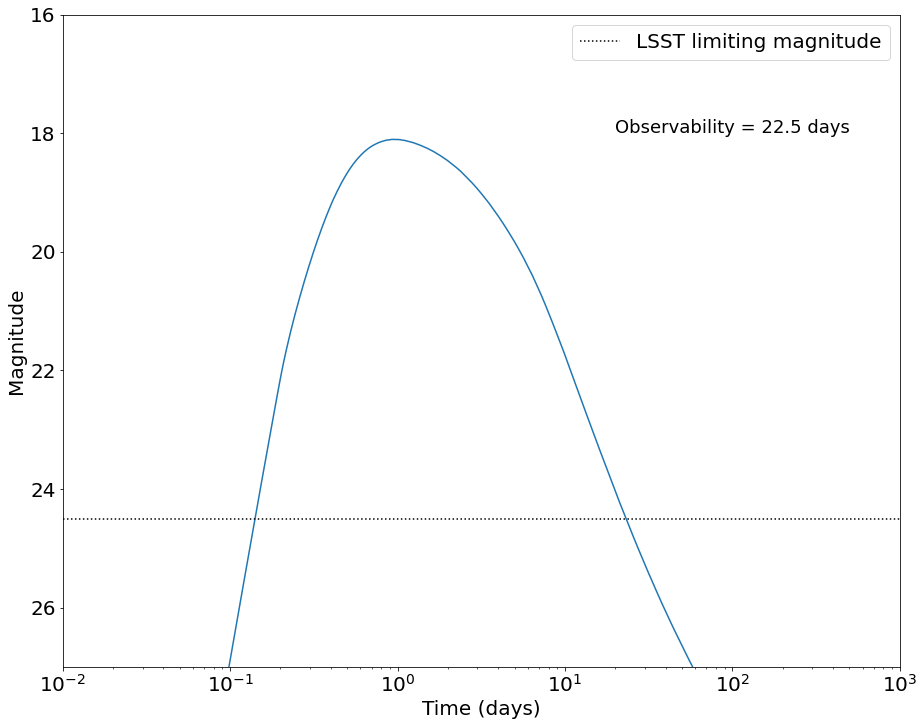

In [30]:
#plt.plot(full_t/86400.+grb_time.mjd, flux_to_mag(full_Fnu_Jy))
plt.plot(full_t/86400., flux_to_mag(full_Fnu_Jy))
plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.axhline(y=24.5, color='black', linestyle=':', label='LSST limiting magnitude')
plt.xlim(0.01,1000)
#plt.xlim(61640,61650)
plt.ylim(27,16)
plt.legend()
plt.text(20, 18, f'Observability = {ObsTime(full_t, flux_to_mag(full_Fnu_Jy)):.1f} days', size=18)
plt.show()

